In [2]:
# Importer les librairies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [4]:
col_names = ["company", 'job', 'degree', 'salary_more_then_100K']
data = pd.read_csv('salaries.csv', header=None, names=col_names)
print(data)

       company                  job      degree  salary_more_then_100K
0      company                  job      degree  salary_more_then_100k
1       google        sale exective  bachelaors                      0
2       google        sale exective     masters                      0
3       google     business manager  bachelaors                      1
4       google     business manager     masters                      1
5       google  computer programmer  bachelaors                      0
6       google  computer programmer     masters                      1
7   abc pharma        sale exective     masters                      0
8   abc pharma  computer programmer  bachelaors                      0
9   abc pharma     business manager  bachelaors                      0
10  abc pharma     business manager     masters                      1
11    facebook        sale exective  bachelaors                      1
12    facebook        sale exective     masters                      1
13    

In [11]:
from sklearn import preprocessing

# Créer un encodeur différent pour chaque colonne catégorielle
company_encoder = preprocessing.LabelEncoder()
job_encoder = preprocessing.LabelEncoder()
degree_encoder = preprocessing.LabelEncoder()

# Encoder les colonnes séparément
data['company'] = company_encoder.fit_transform(data['company'])
data['job'] = job_encoder.fit_transform(data['job'])
data['degree'] = degree_encoder.fit_transform(data['degree'])

# Afficher les premières lignes
print(data.head(9))


   company  job  degree  salary_more_then_100K
0        1    2       1  salary_more_then_100k
1        3    3       0                      0
2        3    3       2                      0
3        3    0       0                      1
4        3    0       2                      1
5        3    1       0                      0
6        3    1       2                      1
7        0    3       2                      0
8        0    1       0                      0


In [12]:
features_cols = ['company', 'job', 'degree']
x = data[features_cols]
y = data['salary_more_then_100K']
#x = data.values[1:, :3]
#y = data.values[1:, 3]   #1:,3 signifi qu'on utilise pas les entetes

In [14]:
print (x)
print(y)

    company  job  degree
0         1    2       1
1         3    3       0
2         3    3       2
3         3    0       0
4         3    0       2
5         3    1       0
6         3    1       2
7         0    3       2
8         0    1       0
9         0    0       0
10        0    0       2
11        2    3       0
12        2    3       2
13        2    0       0
14        2    0       2
15        2    1       0
16        2    1       2
0     salary_more_then_100k
1                         0
2                         0
3                         1
4                         1
5                         0
6                         1
7                         0
8                         0
9                         0
10                        1
11                        1
12                        1
13                        1
14                        1
15                        1
16                        1
Name: salary_more_then_100K, dtype: object


In [15]:
 # separation en training et Test Set

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=100)

In [26]:
#Creation d'un arbre de decision qui utilise l'entropie
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)

#Entrainer l'arbre de decision 
clf_entropy = clf_entropy.fit(x_train, y_train)

#predire les resultats
y_pred = clf_entropy.predict(x_test)

print('accuracy:', metrics.accuracy_score(y_test, y_pred))

accuracy: 0.75


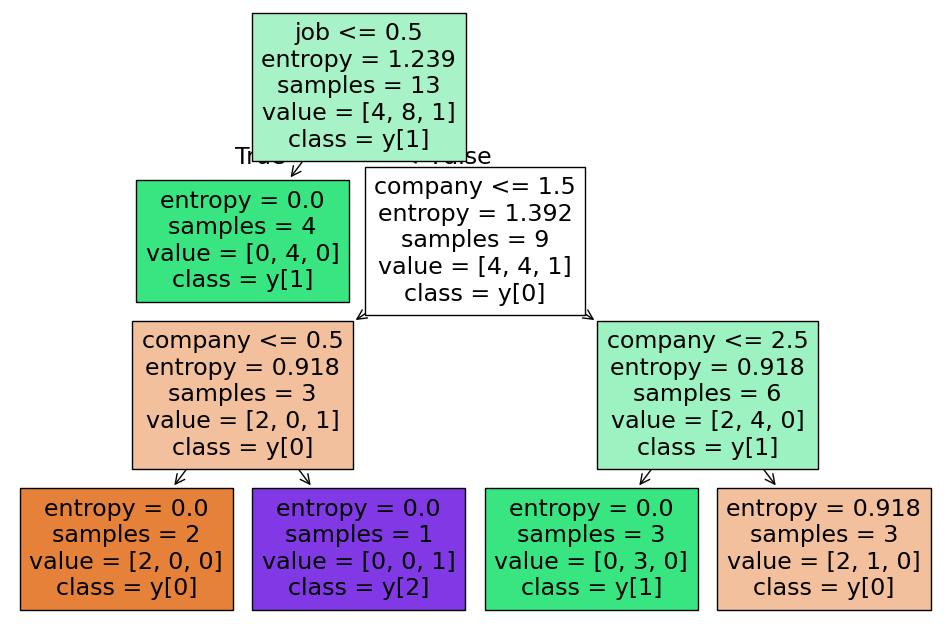

In [28]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf_entropy, filled=True, feature_names=x_train.columns, class_names=True)
plt.show()
